# Modeling- EDA final project

In [1]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

df = pd.read_csv("Medicalpremium.csv")

# Add BMI column
df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)


In [5]:
# Prepare features and targets
X = df.drop("PremiumPrice", axis=1)
y = df["PremiumPrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 788
Testing samples:  198


In [10]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_r2  = r2_score(y_test, lr.predict(X_test))
lr_mae = mean_absolute_error(y_test, lr.predict(X_test))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_r2  = r2_score(y_test, rf.predict(X_test))
rf_mae = mean_absolute_error(y_test, rf.predict(X_test))

print(f"Linear Regression → R²: {lr_r2:.3f} | MAE: ₹{lr_mae:,.0f}") # MAE-Mean Absolute Error
print(f"Random Forest     → R²: {rf_r2:.3f} | MAE: ₹{rf_mae:,.0f}")

Linear Regression → R²: 0.714 | MAE: ₹2,586
Random Forest     → R²: 0.893 | MAE: ₹1,010


In [7]:
# Save the best model
best_model = rf if rf_r2 > lr_r2 else lr

with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved as model.pkl")


Best model saved as model.pkl


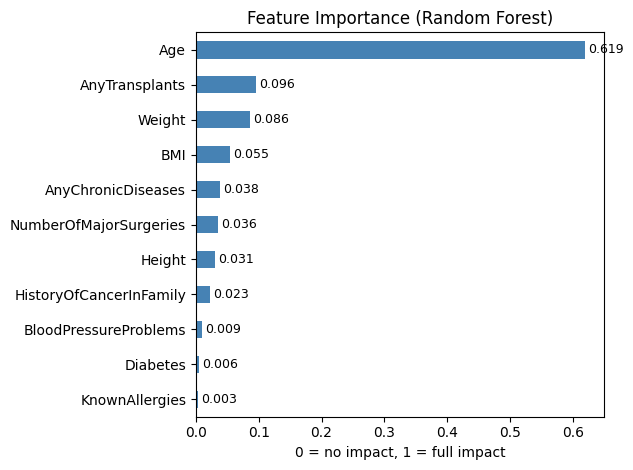

In [12]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
ax = feat_importances.sort_values().plot(kind="barh", color="steelblue")

# Add value labels on each bar
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.005,        # x position (just after the bar)
        bar.get_y() + bar.get_height() / 2,  # y position (center of bar)
        f"{bar.get_width():.3f}",        # label text (3 decimal places)
        va="center", ha="left", fontsize=9
    )

plt.title("Feature Importance (Random Forest)")
plt.xlabel("0 = no impact, 1 = full impact")
plt.tight_layout()
plt.savefig("feature_importance.png")
